In [27]:
%reload_ext autoreload
%autoreload 2

**Environment**

Run the notebook with the project venv (PyTorch on ROCm):

```
cd ~/Desktop/Thesis
source venvs/thesis_rocm/bin/activate
```

The package is imported directly from `Package_Notebook/` via the `sys.path`
append in the next cell — there is no package to `pip install`.

In [36]:
# ---------------------------------------------------------------------------
# Path setup (so Jupyter can import the project package from source)
# ---------------------------------------------------------------------------
import sys
sys.path.append("/home/virthian/Desktop/Thesis/Package_Notebook")

# ---------------------------------------------------------------------------
# Third-party
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------------------------
# This project — single import block (Models/__init__.py is the public API)
# ---------------------------------------------------------------------------
from panelclv.data_preparation import dynamic_panel_dataset
from panelclv.models import (
    MultinomialTransformerModel,  # softmax-over-counts Transformer (classifier head)
    compute_class_weights,  # class weights for weighted_ce / focal
    InferenceMultinomialTransformerModel,  # same backbone, sampling head
    mc_forecast_transformer,  # Transformer holdout rollout (growing-window, stateless)
    mc_compute_metrics,  # RMSE / bias% / aggregate-MAPE
)
from panelclv.training import fit_model
from panelclv.tuning import (
    select_features,  # shared training loop (CE / weighted_ce / focal / emd)
    select_features_for_trial,
    run_optuna_study,  # hyper-parameter search
)
from panelclv.evaluation import (
    weekly_aggregate_predictions,
    plot_weekly_aggregated,
    metrics_table,
)

# Data Loading


In [29]:
from panelclv.configs.panel_config import PanelConfig

csv_path = "Datasets/Dataset_clean/electronics_customer_week_panel.csv"

# One config object replaces DATA_CONFIG + TIME_FEATURES + FEATURE_SCHEMA + INPUT_SPEC.
cfg = PanelConfig(
    # --- identity / target ---
    id_col="Id",
    target_col="Transactions",
    frequency="weekly",
    training_start="1999-01-01", training_end="2000-12-31",
    holdout_start="2001-01-01",  holdout_end="2001-12-31",
    time_cols=("year", "week"),
    clip_target_upper=6,

    # --- engineered time features (OPT-IN: omit -> none are created) ---
    time_features={"add_year_idx": True, "add_week_sin_cos": True},

    # --- feature roles (the target is target_col; don't list it here) ---
    # week_sin / week_cos are auto-added to the 'time' role from the enabled
    # flags above; year_idx is placed explicitly (a trend, not cyclical).
    known_future=("year_idx", "high.season"),
    static=("Gender", "Income"),

    # --- which columns to embed; "auto" infers cardinality from calibration ---
    #   Transactions -> clip_target_upper + 1 = 7
    #   Gender / Income -> (calibration max + 1)   (pin an int to fix the size)
    embedded_cols={"Transactions": "auto", "Gender": "auto", "Income": "auto"},
)

In [30]:
# ---- Monte Carlo forecast settings ----------------------------------------
# Single source of truth for the holdout simulation count: every mc_forecast
# call below uses N_SIMULATIONS, so all models are compared on equal footing.
# Higher -> smoother per-customer mean, more compute. MC_SEED makes the
# forecast reproducible (same model + data + seed -> identical sampled paths).
N_SIMULATIONS = 100
MC_SEED = 42

In [31]:
# ---- 1. Build the (N, T, F) arrays from your config ----------------------
panel     = pd.read_csv(csv_path)

data_full = dynamic_panel_dataset.prepare_dataset(panel, cfg)

# ---- 2. Shape tensors for fit_model --------------------------------------
# samples : (N, T-1, F) float32
# targets : fit_model wants (B, T) long with values in [0, max_trans)
X = data_full["samples"]
y = data_full["targets"].squeeze(-1).astype(np.int64)

# max_trans comes from the RESOLVED spec prepare_dataset returns (handles 'auto').
max_trans = data_full["input_spec"]["embedded_cols"][data_full["target_col"]]
assert y.min() >= 0 and y.max() < max_trans, (
    f"Transactions in [{y.min()}, {y.max()}] but the target embedding caps at {max_trans-1}. "
    f"Raise the cardinality or clip the panel."
)

# ---- 3. Customer-wise train/val split -----------------------------------
train_idx, val_idx = train_test_split(
    np.arange(data_full["N"]), test_size=0.2, random_state=42,
)
# train_loader = DataLoader(
#     TensorDataset(torch.from_numpy(X[train_idx]), torch.from_numpy(y[train_idx])),
#     batch_size=128, shuffle=True,
# )
# val_loader = DataLoader(
#     TensorDataset(torch.from_numpy(X[val_idx]), torch.from_numpy(y[val_idx])),
#     batch_size=128, shuffle=False,
# )

N=829 T_CAL=104 T_HOLD=52 F=7
seq_cols   = ['Transactions', 'week_sin', 'week_cos', 'year_idx', 'high.season', 'Gender', 'Income']
target_col = 'Transactions' at index 0
calibration (829, 104, 7) | samples (829, 103, 7) | targets (829, 103, 1) | holdout (829, 52, 7)
embedded_cols = {'Transactions': 7, 'Gender': 2, 'Income': 10}


## Transformer training & hyperparameter search

### Transformer with Optuna

In [32]:
# ---- 6. data_builder for Optuna -----------------------------------------
# Optuna proposes a feature_config (which removable covariates to drop); we
# rebuild the (N, T-1, F') arrays for that subset, then split with the SAME
# train_idx / val_idx. Mirrors the LSTM notebook.
def data_builder(feature_config, batch_size):
				d  = select_features(data_full, feature_config)
				Xt = d["samples"]
				yt = d["targets"].squeeze(-1).astype(np.int64)

				tr_loader = DataLoader(
								TensorDataset(torch.from_numpy(Xt[train_idx]), torch.from_numpy(yt[train_idx])),
								batch_size=batch_size, shuffle=True,
				)
				va_loader = DataLoader(
								TensorDataset(torch.from_numpy(Xt[val_idx]), torch.from_numpy(yt[val_idx])),
								batch_size=batch_size, shuffle=False,
				)
				metadata = {
								"seq_cols":   d["seq_cols"],
								"input_spec": d["input_spec"],
								"target_col": d["target_col"],
								"seq_len":    Xt.shape[1],
				}
				return tr_loader, va_loader, metadata

### Loss trials

In [33]:
# ---- 5. (Optional) class weights for focal / weighted_ce -----------------
# Skip the next two lines for the paper-faithful CE run.
LOSS_TYPE     = "cross_entropy"            # 'cross_entropy' | 'weighted_ce' | 'focal' | 'emd'
class_weights = compute_class_weights(y[train_idx], num_classes=max_trans)
print("class_weights:", class_weights.tolist())

class_weights: [0.0023326866794377565, 0.2251127064228058, 0.33963513374328613, 0.7777644395828247, 1.5712412595748901, 2.3931212425231934, 1.6907923221588135]


## Optuna optimization cross entropy

In [34]:
# ---- 7. Run the Transformer Optuna study --------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
STUDY_NAME = f"transformer_{LOSS_TYPE}_3"            # one study per loss → no schema collisions

transformer_study = run_optuna_study(
    model_type="transformer",
    data_builder=data_builder,
    data_info={
        "n_epochs":       150,
        "patience":       7,
        "checkpoint_dir": "./checkpoints/transformer_optuna",
        "verbose":        False,
        # Loss configuration (all four read from data_info — unused keys are ignored).
        "loss_type":      LOSS_TYPE,
        "class_weights":  class_weights    # used by 'weighted_ce' / 'focal'; harmless for 'cross_entropy'
    },
    removable_features=["Gender", "Income", "high.season", "year_idx", ("week_sin", "week_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    device=device,
    n_trials=10,                            # 64 archs × 9 dropout points × 3 batches — give TPE room
    study_name=STUDY_NAME,
    summary_dir="./optuna_summaries"
)

print("best trial   :", transformer_study.best_trial.number)
print("best val loss:", transformer_study.best_trial.value)
print("best params  :", transformer_study.best_trial.params)
print("checkpoint   :", transformer_study.best_trial.user_attrs["checkpoint_path"])


[I 2026-05-31 18:43:05,316] A new study created in memory with name: transformer_cross_entropy_3_20260531_1843


[I 2026-05-31 18:43:15,671] Trial 0 finished with value: 0.1478239744901657 and parameters: {'d_model': 64, 'nhead': 2, 'num_encoder_layers': 1, 'dropout': 0.3464704583099741, 'learning_rate': 0.0007725378389307352, 'weight_decay': 0.0006796578090758161, 'batch_size': 128, 'use_Gender': True, 'use_Income': False, 'use_high.season': True, 'use_year_idx': False, 'use_week_sin+week_cos': False}. Best is trial 0 with value: 0.1478239744901657.
[I 2026-05-31 18:43:21,385] Trial 1 finished with value: 0.15514744073152542 and parameters: {'d_model': 128, 'nhead': 8, 'num_encoder_layers': 1, 'dropout': 0.24301794076057537, 'learning_rate': 0.0001786013788939711, 'weight_decay': 1.8205657658407268e-06, 'batch_size': 128, 'use_Gender': True, 'use_Income': True, 'use_high.season': False, 'use_year_idx': False, 'use_week_sin+week_cos': False}. Best is trial 0 with value: 0.1478239744901657.
[I 2026-05-31 18:43:30,520] Trial 2 finished with value: 0.15037256479263306 and parameters: {'d_model': 128

best trial   : 7
best val loss: 0.1454758271574974
best params  : {'d_model': 64, 'nhead': 4, 'num_encoder_layers': 1, 'dropout': 0.01631005662190557, 'learning_rate': 0.0007461403484816761, 'weight_decay': 0.0005131654955148327, 'batch_size': 128, 'use_Gender': True, 'use_Income': True, 'use_high.season': True, 'use_year_idx': True, 'use_week_sin+week_cos': True}
checkpoint   : checkpoints/transformer_optuna/transformer_cross_entropy_3_20260531_1843/transformer_trial_7.pth


## Optuna rollout

In [ ]:
# ---- 7. Run the Transformer Optuna study --------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
STUDY_NAME = f"transformer_{LOSS_TYPE}_rollout_composite"   # fresh name: composite score is a different scale than val-CE — never share a val_loss study's storage

transformer_study = run_optuna_study(
				model_type="transformer",
				selection_metric="rollout_composite",  # select on the autoregressive rollout, not teacher-forced val loss
				rollout_data=data_full,                # full data; the study carves a leak-free pseudo-holdout from the calibration tail internally
				val_idx=val_idx,                       # rollout scored on the same validation customers as the val loss
				rollout_horizon=52,                    # match the real holdout length
				rollout_n_simulations=30,              # LOWER than the LSTM's 100: the Transformer rollout is stateless / growing-window (O(t) per step), so each trial is much costlier
				data_builder=data_builder,
				data_info={
								"n_epochs":       100,
								"patience":       10,
								"checkpoint_dir": "./checkpoints/transformer_optuna",
								"verbose":        False,
								# Loss configuration (all read from data_info — unused keys are ignored).
								"loss_type":      LOSS_TYPE,
								"class_weights":  class_weights,   # used by 'weighted_ce' / 'focal'; harmless for 'cross_entropy'
				},
				removable_features=["Gender", "Income", "high.season", "year_idx", ("week_sin", "week_cos")],
				device=device,
				n_trials=30,                           # transformer rollout is slow; start modest, raise if you have time budget
				study_name=STUDY_NAME,
				summary_dir="./optuna_summaries",
				storage="sqlite:///optuna_summaries/transformer_rollout.db",  # separate DB from the LSTM study
)

print("best trial   :", transformer_study.best_trial.number)
print("best val loss:", transformer_study.best_trial.value)
print("best params  :", transformer_study.best_trial.params)
print("checkpoint   :", transformer_study.best_trial.user_attrs["checkpoint_path"])

In [37]:
# ---- 8. Rebuild the Transformer with the Optuna-selected arch + load weights ----
best        = transformer_study.best_trial
best_params = best.params
CHECKPOINT  = transformer_study.best_trial.user_attrs["checkpoint_path"]
data_best = select_features_for_trial(data_full, best)

inference_model = InferenceMultinomialTransformerModel(
    seq_cols=data_best["seq_cols"],
    input_spec=data_best["input_spec"],
    target_col=data_best["target_col"],
    d_model=best_params["d_model"],
    nhead=best_params["nhead"],
    num_encoder_layers=best_params["num_encoder_layers"],
    dropout=best_params["dropout"],
    mode="sample",
)

state = torch.load(CHECKPOINT, map_location="cpu")
# Training-time Transformer registers a `_cached_mask` buffer for the fixed-
# length training pass; the inference model regenerates the mask on the fly,1
# so drop the unexpected key before loading.
state.pop("_cached_mask", None)
inference_model.load_state_dict(state)

<All keys matched successfully>

In [38]:
# ---- 9. Valendin-style autoregressive Monte Carlo forecast ---------------
# The Transformer is STATELESS: unlike the LSTM (which threads a hidden state
# forward), it has to re-attend over the actual history at every step. So the
# Transformer rollout uses a GROWING context window — `mc_forecast_transformer`
# warms up on the full calibration window, then for each holdout period re-feeds
# [calibration + already-sampled holdout] and reads the last position. This keeps
# the positional encoding consistent with training (calibration at 0..T_CAL-1,
# holdout step t at T_CAL+t). True holdout counts are never fed back — only the
# model's own samples are (no leakage).
forecast = mc_forecast_transformer(
    inference_model,
    data_full,
    n_simulations=N_SIMULATIONS,   # average this many sampled paths -> expected count
    device=device,
    seed=MC_SEED,                  # reproducible: same model + data + seed -> identical paths
)

# Guard against a stale (not-re-run) cell silently reporting an old count.
assert forecast["simulations"].shape[0] == forecast["n_simulations"] == N_SIMULATIONS

print("simulations shape:", forecast["simulations"].shape)        # (S, N, T_HOLD)
print("prediction mean  :", forecast["prediction_mean"].shape)    # (N, T_HOLD)
print("actual (real)    :", forecast["actual"].shape)             # (N, T_HOLD)

simulations shape: (100, 829, 52)
prediction mean  : (829, 52)
actual (real)    : (829, 52)


In [39]:
# ---- 10. Score + sanity check -------------------------------------------
metrics = mc_compute_metrics(forecast["actual"], forecast["prediction_mean"])
print(metrics)

# Aggregate predicted vs actual per week (useful for the thesis plot).
agg_pred   = forecast["prediction_mean"].sum(axis=0)              # (T_HOLD,)
agg_actual = forecast["actual"].sum(axis=0)
for i in range(min(20, len(agg_pred))):
    print(f"  week {i:>2}  pred={agg_pred[i]:6.1f}  actual={agg_actual[i]:6.1f}")

{'rmse': 0.37734711944540467, 'bias_percent': 27.500340135561096, 'mape_aggregate_style': 51.29311486276218}
  week  0  pred=  38.8  actual=  46.0
  week  1  pred=  34.5  actual=  54.0
  week  2  pred=  34.7  actual=  64.0
  week  3  pred=  39.1  actual=  42.0
  week  4  pred=  42.5  actual=  40.0
  week  5  pred=  45.0  actual=  51.0
  week  6  pred=  46.1  actual=  40.0
  week  7  pred=  46.7  actual=  37.0
  week  8  pred=  46.3  actual=  15.0
  week  9  pred=  45.7  actual=   8.0
  week 10  pred=  42.3  actual=  16.0
  week 11  pred=  38.9  actual=  23.0
  week 12  pred=  33.3  actual=  13.0
  week 13  pred=  31.6  actual=   7.0
  week 14  pred=  29.7  actual=  23.0
  week 15  pred=  30.3  actual=  34.0
  week 16  pred=  34.6  actual=   6.0
  week 17  pred=  34.0  actual=  24.0
  week 18  pred=  33.5  actual=  12.0
  week 19  pred=  32.2  actual=   6.0


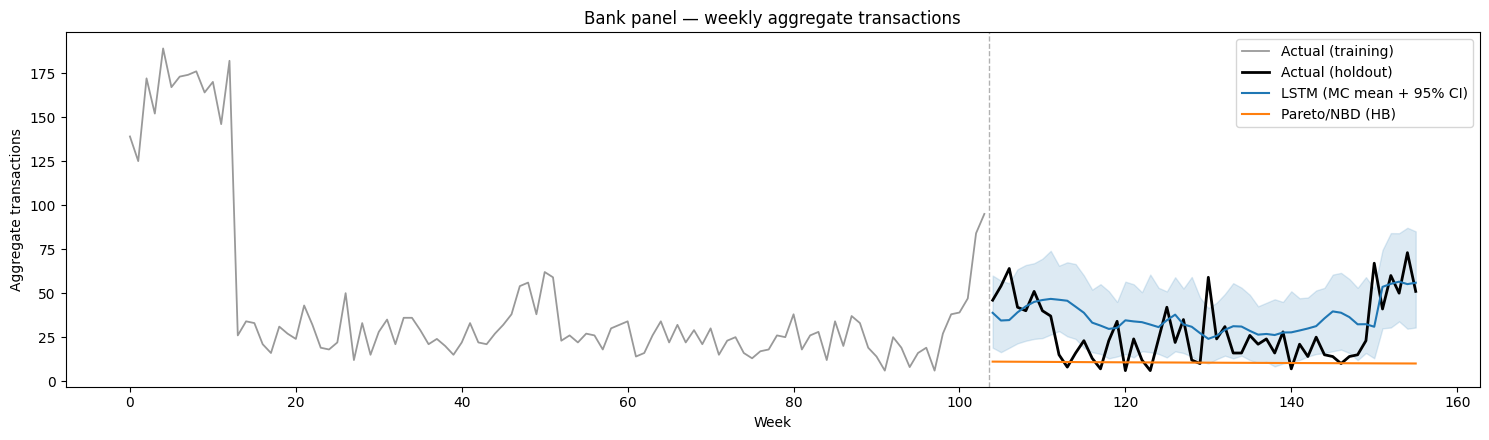

In [40]:
# Aggregate actuals across customers per holdout week.
actuals = forecast["actual"].sum(axis=0)            # (T_HOLD,)

# (Optional) training-window aggregate to show context to the left of the holdout.
# data_full["calibration"] is (N, T_CAL, F); the target column lives at target_idx.
target_idx    = data_full["seq_cols"].index(data_full["target_col"])
train_actuals = data_full["calibration"][..., target_idx].sum(axis=0)   # (T_CAL,)

# Add a trailing 1-axis so weekly_aggregate_predictions takes the (S, N, T, 1)
# branch and draws the 95% MC ribbon.
mc_sims = forecast["simulations"][..., None]        # (S, N, T_HOLD, 1)

fig, ax = plot_weekly_aggregated(
				actuals=actuals,
    data=data_best,
    pareto_paper_benchmark=True,      
				predictions_by_model={"LSTM (MC mean + 95% CI)": mc_sims},
				train_actuals=train_actuals,                    # omit to plot only the holdout
				title="Bank panel — weekly aggregate transactions",
				show_ci=True,
				# save_path="figures/bank_lstm_weekly.png",    # uncomment to save
)
